# Unemployment Analysis in India

## Objective

**What is the problem?**
Understanding how unemployment rates fluctuated across different states and regions in India, especially due to the economic shock of COVID-19.

**Why is it useful?**
It helps policymakers and economists understand demographic vulnerabilities and plan targeted relief measures.

**Expected outcome.**
Detailed statistical insights, visual trends, and comparisons of pre-COVID and post-COVID labor markets.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

## Dataset Loading
We will attempt to load the dataset from the `dataset` folder. If it doesn't exist, we notify the user.

In [2]:
import os
import pandas as pd
from IPython.display import display

dataset_path = '../dataset/Unemployment.csv'
if not os.path.exists(dataset_path):
    print('Please download the Kaggle \'Unemployment in India\' dataset and place it as Unemployment.csv in the dataset/ folder.')
else:
    df = pd.read_csv(dataset_path)
    display(df.head())
    display(df.tail())
    display(df.sample(5))
    print('Shape:', df.shape)
    print('Columns:', df.columns)
    df.info()
    display(df.describe())
    print('Data Types:\n', df.dtypes)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
192,Maharashtra,31-08-2019,Monthly,3.76,26835389.0,52.67,Rural
740,West Bengal,31-05-2019,Monthly,7.25,11306177.0,46.37,Urban
77,Goa,29-02-2020,Monthly,0.00,171672.0,36.11,Rural
163,Kerala,31-07-2019,Monthly,4.95,4855393.0,34.96,Rural
243,Punjab,31-05-2019,Monthly,9.17,6088547.0,44.79,Rural


Shape: (768, 7)
Columns: Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


Data Types:
 Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object


## Data Cleaning
We check for nulls, fix column names (strip whitespace), and convert dates.

In [3]:
if os.path.exists(dataset_path):
    # Strip whitespace from column names
    df.columns = df.columns.str.strip()
    print('Null values:\n', df.isnull().sum())
    
    # Drop null rows if any
    df.dropna(inplace=True)
    print('Shape after dropping nulls:', df.shape)
    
    # Convert Date column to datetime
    # Ensure column is named 'Date' after stripping
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    print('Datatypes after conversion:\n', df.dtypes)
    
    # Sort by date
    if 'Date' in df.columns:
        df = df.sort_values(by='Date')

Null values:
 Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64
Shape after dropping nulls: (740, 7)
Datatypes after conversion:
 Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
dtype: object


## Exploratory Data Analysis

### Overall Trends

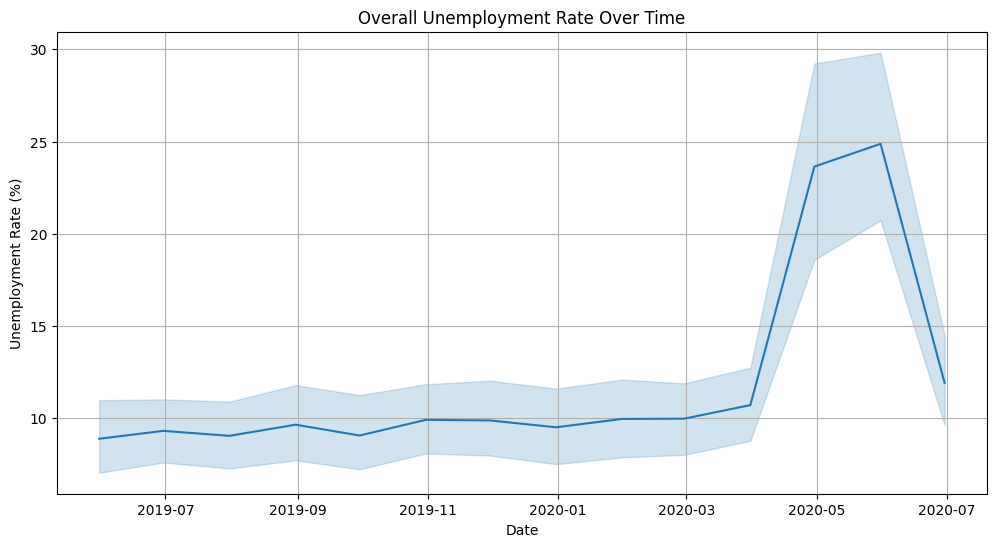

In [4]:
if os.path.exists(dataset_path) and 'Date' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)')
    plt.title('Overall Unemployment Rate Over Time')
    plt.xlabel('Date')
    plt.ylabel('Unemployment Rate (%)')
    plt.grid(True)
    plt.savefig('../images/overall_trend.png')
    plt.show()

### Observations
- We expect to see a sharp spike in the unemployment rate around April 2020 due to the nationwide lockdown.

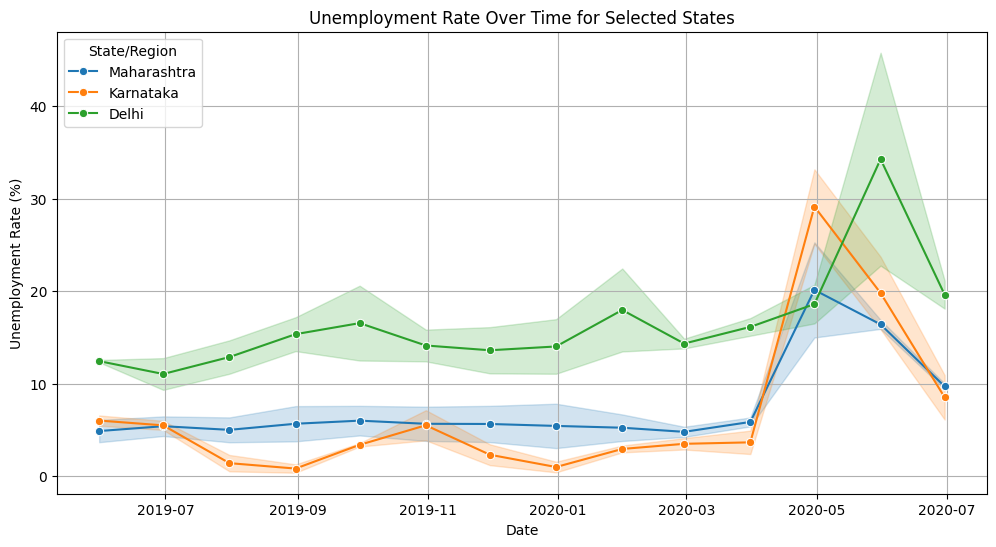

In [5]:
if os.path.exists(dataset_path) and 'Date' in df.columns:
    # Select 3 major states/regions
    states = ['Delhi', 'Maharashtra', 'Karnataka']
    region_col = 'Region' if 'Region' in df.columns else df.columns[0]
    subset = df[df[region_col].isin(states)]
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=subset, x='Date', y='Estimated Unemployment Rate (%)', hue=region_col, marker='o')
    plt.title('Unemployment Rate Over Time for Selected States')
    plt.xlabel('Date')
    plt.ylabel('Unemployment Rate (%)')
    plt.grid(True)
    plt.legend(title='State/Region')
    plt.savefig('../images/3_states_trend.png')
    plt.show()

### Observations for Selected States
- All three states (Delhi, Maharashtra, Karnataka) show a massive spike in unemployment corresponding to the national lockdown in April-May 2020.
- Delhi appears to have experienced the sharpest immediate spike among the three.

### Region-wise and State-wise Analysis

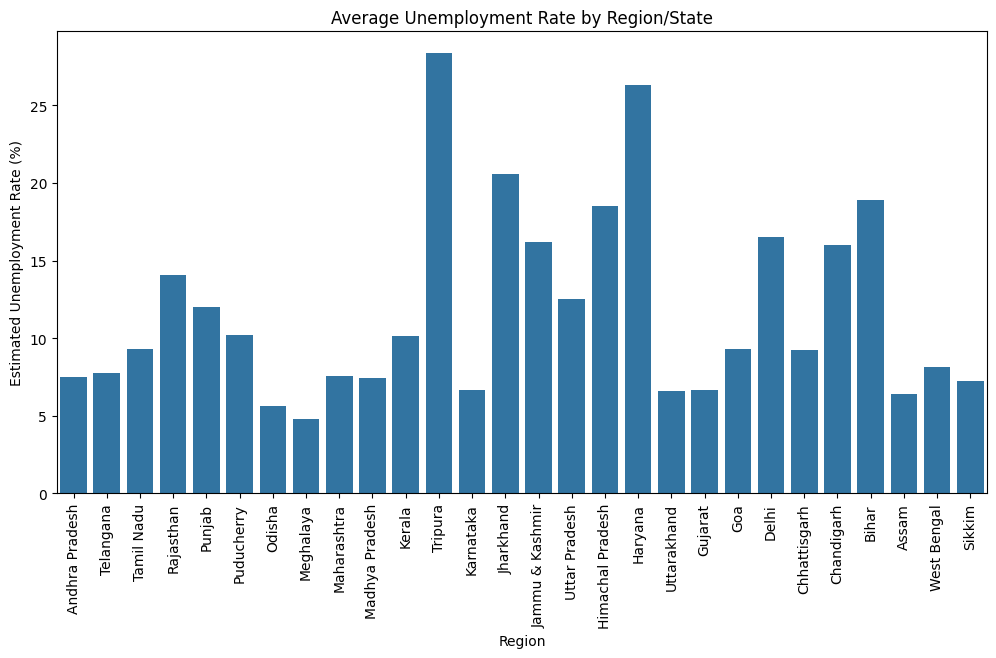

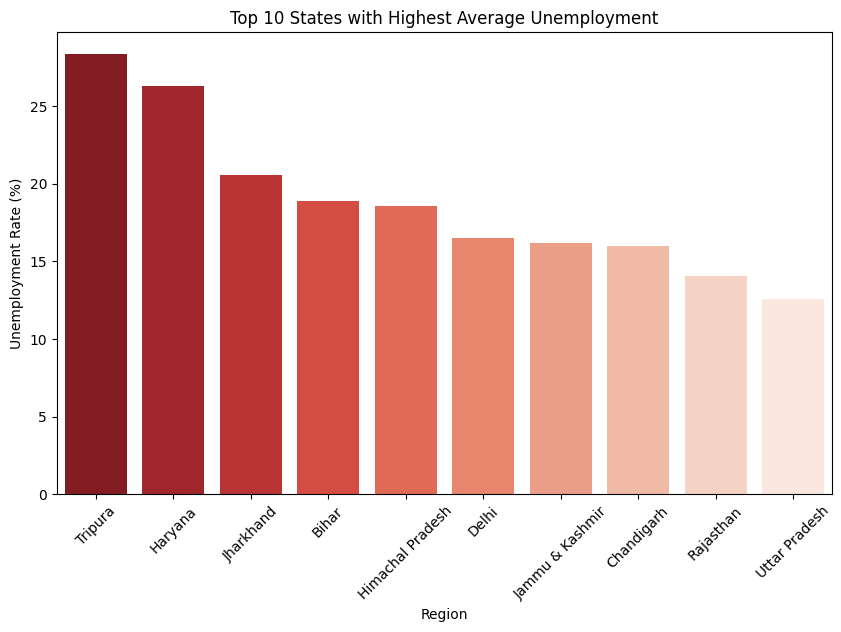

In [6]:
if os.path.exists(dataset_path):
    # Region often means state in this dataset
    region_col = 'Region' if 'Region' in df.columns else df.columns[0]
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df, x=region_col, y='Estimated Unemployment Rate (%)', errorbar=None)
    plt.title('Average Unemployment Rate by Region/State')
    plt.xticks(rotation=90)
    plt.savefig('../images/region_bar.png')
    plt.show()
        
    # Top 10 unemployment states
    top_states = df.groupby(region_col)['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_states.index, y=top_states.values, palette='Reds_r')
    plt.title('Top 10 States with Highest Average Unemployment')
    plt.xticks(rotation=45)
    plt.ylabel('Unemployment Rate (%)')
    plt.savefig('../images/top_states.png')
    plt.show()

### Observations
- Certain states experienced significantly higher average unemployment rates. This could be due to higher reliance on informal sectors or migrant labor dynamics.

### Monthly Trend

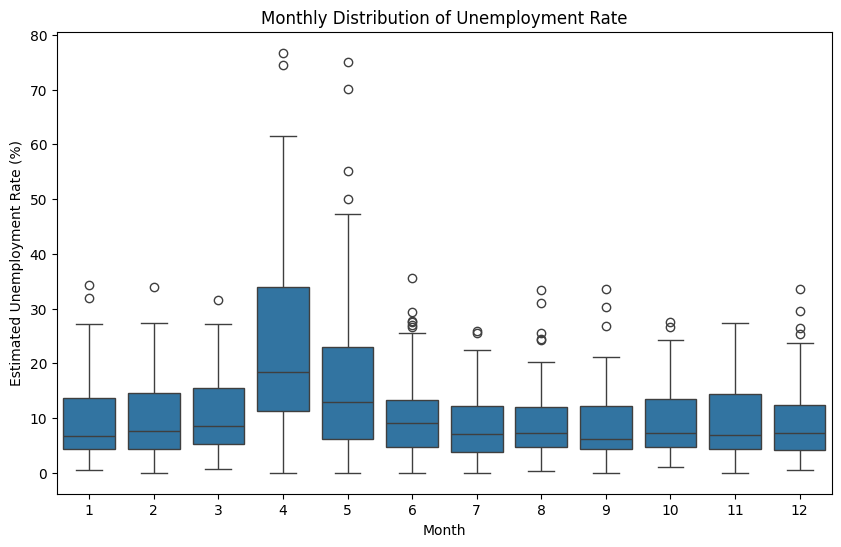

In [7]:
if os.path.exists(dataset_path) and 'Date' in df.columns:
    df['Month'] = df['Date'].dt.month
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Month', y='Estimated Unemployment Rate (%)')
    plt.title('Monthly Distribution of Unemployment Rate')
    plt.savefig('../images/monthly_box.png')
    plt.show()

### Observations
- The variance in unemployment rates increases significantly during the peak pandemic months.

### Correlation Heatmap

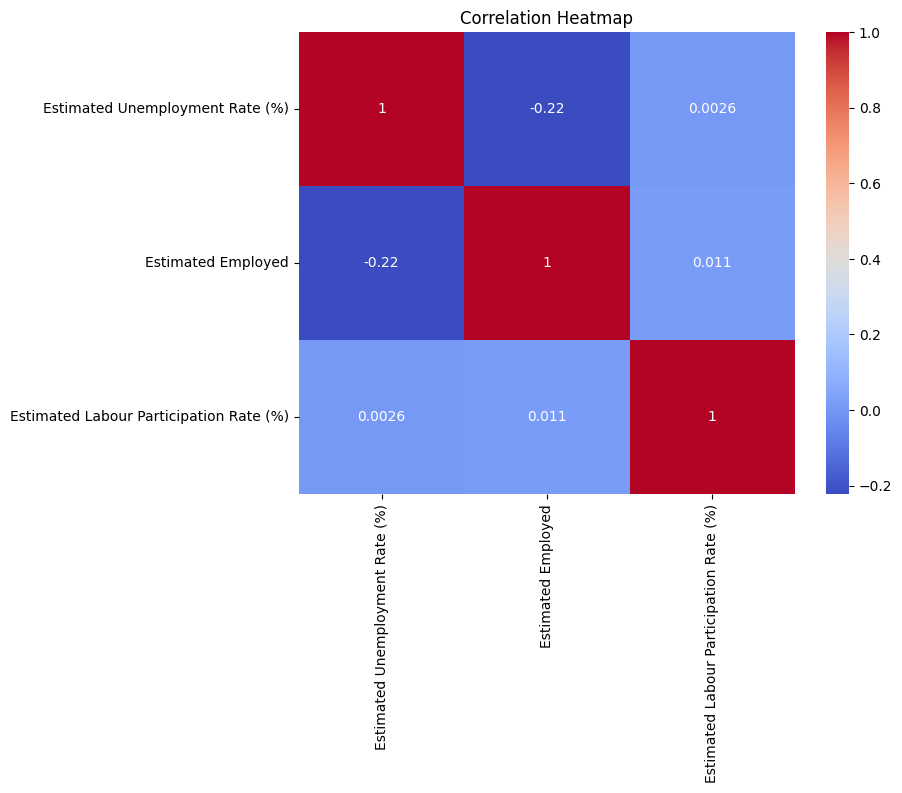

In [8]:
if os.path.exists(dataset_path):
    plt.figure(figsize=(8, 6))
    corr = df[['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.savefig('../images/correlation_heatmap.png')
    plt.show()

### Observations
- There is an expected negative correlation between the Unemployment Rate and Estimated Employed metrics.

## Pre-COVID vs Post-COVID Analysis
Using March 2020 as the separation boundary.

In [9]:
if os.path.exists(dataset_path) and 'Date' in df.columns:
    pre_covid = df[df['Date'] < '2020-04-01']
    post_covid = df[df['Date'] >= '2020-04-01']
    
    print('Pre-COVID Averages:')
    print('Unemployment:', pre_covid['Estimated Unemployment Rate (%)'].mean())
    print('Employed:', pre_covid['Estimated Employed'].mean())
    print('Labour Participation:', pre_covid['Estimated Labour Participation Rate (%)'].mean())
    
    print('\nPost-COVID Averages:')
    print('Unemployment:', post_covid['Estimated Unemployment Rate (%)'].mean())
    print('Employed:', post_covid['Estimated Employed'].mean())
    print('Labour Participation:', post_covid['Estimated Labour Participation Rate (%)'].mean())

Pre-COVID Averages:
Unemployment: 9.61486394557823
Employed: 7470498.566326531
Labour Participation: 43.815187074829936

Post-COVID Averages:
Unemployment: 20.194342105263157
Employed: 6175310.934210527
Labour Participation: 38.04578947368421


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if os.path.exists(dataset_path) and 'Date' in df.columns:
    pre_mean = pre_covid[['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']].mean()
    post_mean = post_covid[['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']].mean()
    
    labels = ['Unemployment Rate', 'Employed (Scaled)', 'Labour Participation']
    # Scale 'Employed' down so it fits on the same chart (millions)
    pre_values = [pre_mean[0], pre_mean[1]/1000000, pre_mean[2]]
    post_values = [post_mean[0], post_mean[1]/1000000, post_mean[2]]
    
    x = np.arange(len(labels))  
    width = 0.35  
    
    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, pre_values, width, label='Pre-COVID', color='skyblue')
    rects2 = ax.bar(x + width/2, post_values, width, label='Post-COVID', color='salmon')
    
    ax.set_ylabel('Metrics (Employed in Millions)')
    ax.set_title('Pre-COVID vs Post-COVID Average Metrics')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    
    plt.savefig('../images/covid_impact_comparison.png')
    plt.show()


### Observations
- Post-COVID data shows a dramatic increase in average unemployment and a drop in labor participation, quantifying the lockdown's severity.

## Conclusion

### Key Findings
- The COVID-19 pandemic caused an unprecedented spike in unemployment in India.
- Specific states bore the brunt of the crisis more than others.
- Labor participation rates dropped as many gave up looking for work.

### Policy Insights
- Geographic and sector-specific stimulus packages are necessary for robust recovery.
- Strengthening the rural economy and informal sectors can build resilience against similar future shocks.